# Coordinate To Image Training

This notebook is only the orchestration layer.
The actual code lives in:
- `model/load.py`
- `model/model.py`
- `model/train.py`
- `model/checkpoints.py`


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == 'model' else cwd
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from model.checkpoints import latest_checkpoint, list_checkpoints
from model.load import FingerVideoDataset
from model.model import CoordinateToImageUNet
from model.train import (
    load_checkpoint,
    make_train_val_loaders,
    predict_frames,
    train_or_load_model,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('repo_root:', repo_root)
print('device:', device)


repo_root: /workspace/worldmodel
device: cuda


In [2]:
PROCESSED_DIR = repo_root / 'data/processed-finger-sam-2026-01-30T22-41-47-949Z'
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 20
LR = 1e-3
CHECKPOINT_ROOT = repo_root / 'model/checkpoints'
RUN_NAME = 'coord_to_image_unet'
PREFER_EXISTING_CHECKPOINT = True

dataset = FingerVideoDataset(PROCESSED_DIR, image_size=IMAGE_SIZE)
print('dataset size:', len(dataset))
print('latest matching checkpoint:', latest_checkpoint(root=CHECKPOINT_ROOT, glob_pattern=f'{RUN_NAME}*.pt'))

train_loader, val_loader = make_train_val_loaders(
    PROCESSED_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    val_fraction=0.1,
)

sample_coords, sample_frame = dataset[0]
print('sample coords shape:', sample_coords.shape)
print('sample frame shape:', sample_frame.shape)


dataset size: 292
latest matching checkpoint: /workspace/worldmodel/model/checkpoints/coord_to_image_unet_2026-03-13T19-20-32Z.pt
sample coords shape: torch.Size([2])
sample frame shape: torch.Size([3, 128, 128])


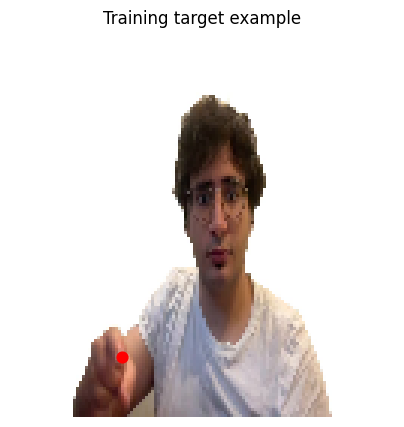

In [3]:
coords, frame = dataset[10]
img = frame.permute(1, 2, 0).cpu().numpy()
x = coords[0].item() * img.shape[1]
y = coords[1].item() * img.shape[0]

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.scatter([x], [y], c='red', s=60)
plt.title('Training target example')
plt.axis('off')
plt.show()


In [4]:
model = CoordinateToImageUNet(image_size=IMAGE_SIZE[0])
model, history, loaded_extra, checkpoint_path, loaded_from_checkpoint = train_or_load_model(
    model,
    train_loader,
    val_loader,
    run_name=RUN_NAME,
    checkpoint_root=CHECKPOINT_ROOT,
    prefer_existing_checkpoint=PREFER_EXISTING_CHECKPOINT,
    device=device,
    epochs=EPOCHS,
    lr=LR,
    extra={
        'run_name': RUN_NAME,
        'image_size': IMAGE_SIZE,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'lr': LR,
        'processed_dir': str(PROCESSED_DIR),
    },
)
print('checkpoint path:', checkpoint_path)
print('loaded_from_checkpoint:', loaded_from_checkpoint)
print('loaded_extra:', loaded_extra)


checkpoint path: /workspace/worldmodel/model/checkpoints/coord_to_image_unet_2026-03-13T19-20-32Z.pt
loaded_from_checkpoint: True
loaded_extra: {'run_name': 'coord_to_image_unet', 'image_size': (128, 128), 'batch_size': 16, 'epochs': 20, 'lr': 0.001, 'processed_dir': '/workspace/worldmodel/data/processed-finger-sam-2026-01-30T22-41-47-949Z'}


In [5]:
all_checkpoints = list_checkpoints(root=CHECKPOINT_ROOT)
for info in all_checkpoints:
    print(info.path)


/workspace/worldmodel/model/checkpoints/auto_save_smoke_2026-03-13T19-20-12Z.pt
/workspace/worldmodel/model/checkpoints/coord_to_image_unet.pt
/workspace/worldmodel/model/checkpoints/coord_to_image_unet_2026-03-13T19-20-32Z.pt


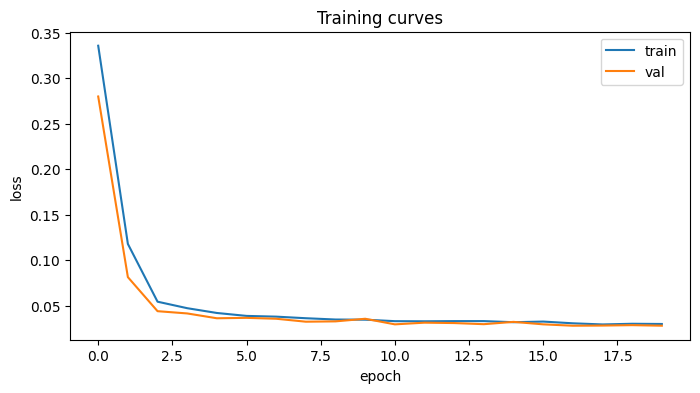

In [6]:
if history is not None:
    plt.figure(figsize=(8, 4))
    plt.plot(history.train_losses, label='train')
    plt.plot(history.val_losses, label='val')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Training curves')
    plt.legend()
    plt.show()
else:
    print('No new training run happened in this session because an existing checkpoint was loaded.')


In [7]:
reloaded_model = CoordinateToImageUNet(image_size=IMAGE_SIZE[0]).to(device)
reloaded_model, reloaded_history, reloaded_extra = load_checkpoint(
    checkpoint_path,
    reloaded_model,
    device=device,
)
print('reloaded checkpoint from', checkpoint_path)
print('reloaded extra:', reloaded_extra)


reloaded checkpoint from /workspace/worldmodel/model/checkpoints/coord_to_image_unet_2026-03-13T19-20-32Z.pt
reloaded extra: {'run_name': 'coord_to_image_unet', 'image_size': (128, 128), 'batch_size': 16, 'epochs': 20, 'lr': 0.001, 'processed_dir': '/workspace/worldmodel/data/processed-finger-sam-2026-01-30T22-41-47-949Z'}


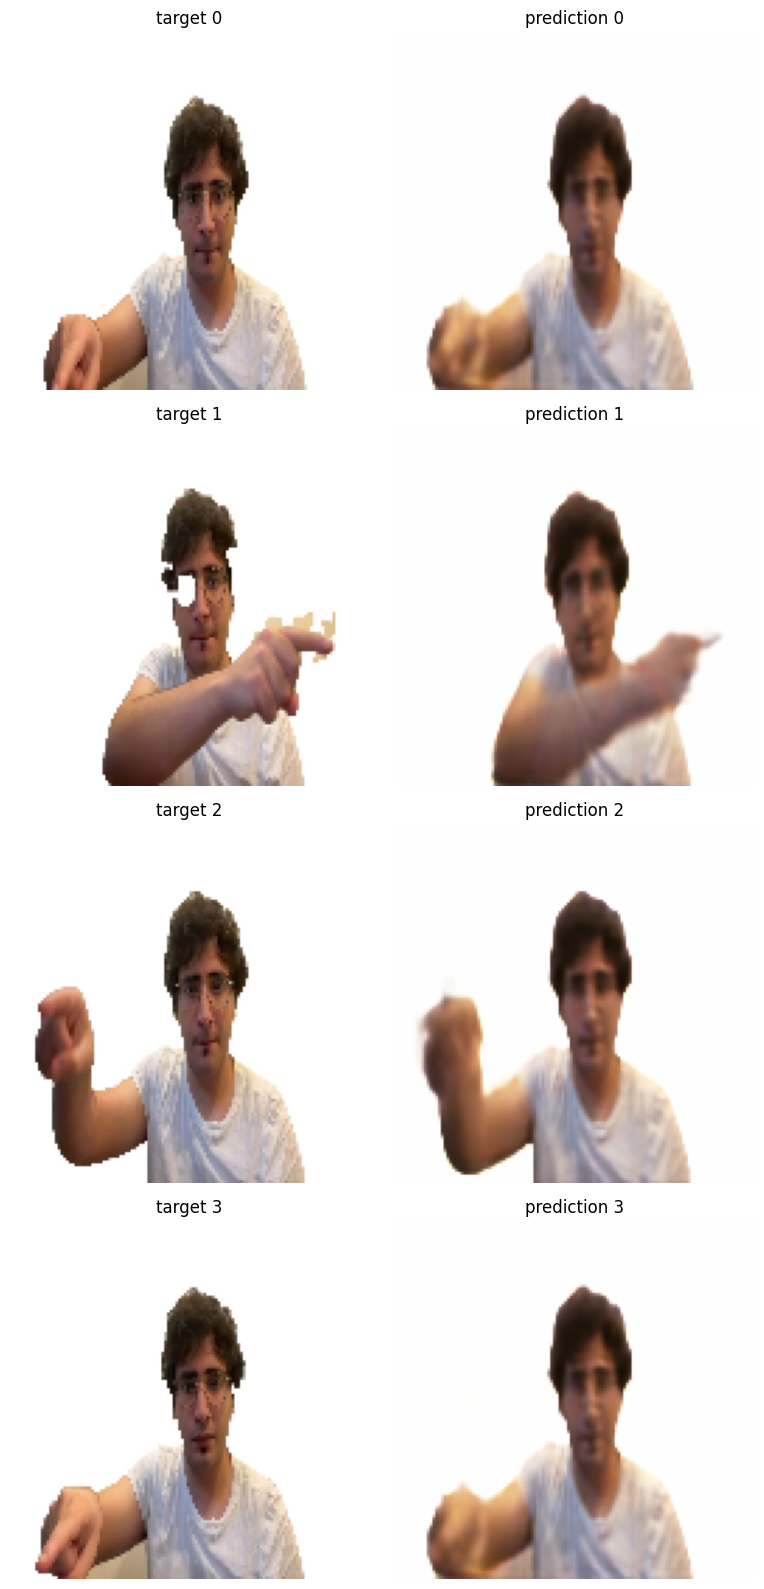

In [8]:
val_coords, val_frames = next(iter(val_loader))
pred_frames = predict_frames(reloaded_model, val_coords[:4], device=device)
target_frames = val_frames[:4]

fig, axes = plt.subplots(4, 2, figsize=(8, 16))
for row in range(4):
    target = target_frames[row].permute(1, 2, 0).cpu().numpy()
    pred = pred_frames[row].permute(1, 2, 0).cpu().numpy()
    axes[row, 0].imshow(target)
    axes[row, 0].set_title(f'target {row}')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(pred)
    axes[row, 1].set_title(f'prediction {row}')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()
